In [9]:
import numpy as np
import cupy as cp
from matplotlib import pyplot as plt
import math
from tqdm.notebook import tqdm
from numba import njit
import sys

In [10]:
def riemann(a, b, n, f):
    x = np.linspace(a, b, n, endpoint=False)
    h = (b - a) / n
    return h * np.sum(f(x))

def trapezoid(a, b, n, f):
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    return h * np.sum(f(x)[:-1]) + 0.5 * h * (f(b) - f(a))

In [11]:
N = np.arange(11)
errs_riemann = np.abs(np.array([riemann(0, np.pi, 2**n, lambda x: np.tan(x)) for n in tqdm(N)]))
errs_trapezoid = np.abs(np.array([trapezoid(0, np.pi, 2**n, lambda x: np.tan(x)) for n in tqdm(N)]))

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

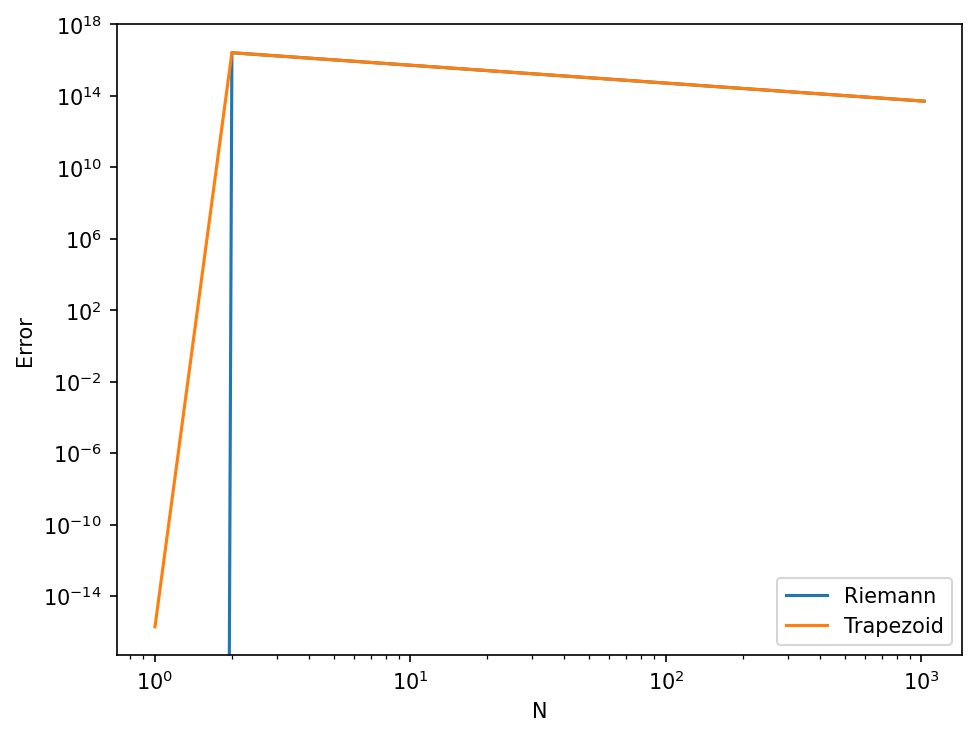

In [12]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(2**N, errs_riemann, label="Riemann")
plt.plot(2**N, errs_trapezoid, label="Trapezoid")
plt.ylabel("Error")
plt.xlabel("N")
plt.yscale("log")
plt.xscale("log")
plt.legend()